Si consideri il data set sintetico presente nel file data.csv costituito da 3000 punti con 15 feature numeriche cadauno e una label binaria di classe con valori appartenenti a {0, 1}. 

1. Caricare il dataset, estrarre randomicamente un test set pari al 5% dei dati, mantenendo il restante 95% come training set vero e proprio. Calcolare e stampare la matrice di correlazione tra le feature e trasformare gli eventuali dati multicollineari con una opportuna combinazione lineare. Infine selezionare le feature rilevanti tramite il Fisher score.

In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif

df = pd.read_csv('data.csv', sep=',')
print(df)

X = df.drop('class', axis=1)
y = df['class']

X_tr, X_test, y_tr, y_test = train_test_split(X, y, test_size=0.05, random_state=42, stratify=y)

#dati mancanti
report_missing = X_tr.isnull().sum() / len(X_tr)*100
print(report_missing)
#nessuna prsenza di dati mancanti -> imputazione non necessaria


#multicollinearità
corr_matrix = X_tr.corr().abs()
corr_pairs = corr_matrix.unstack().drop_duplicates()
corr_pairs = corr_pairs[corr_pairs != 1.0]
print(corr_pairs)
corr_threshold = 0.6
related_features = corr_pairs[corr_pairs > corr_threshold]
print(related_features)
#da qui sorgono delle correlazioni tra le feature

#trasformazione dei dati multicollineari tramite combinazione lineare -> PCA
corr_features =['feature_4', 'feature_7', 'feature_8', 'feature_13']  #prelevo le feature altamente correlate con la prima
principal_components = PCA(n_components=1)
new_feature_tr = principal_components.fit_transform(X_tr[corr_features])
new_feature_test = principal_components.transform(X_test[corr_features])
#aggiungo la nuova feature ottenuta in entrambi i set
X_tr['PCA_features'] = new_feature_tr
X_test['PCA_features'] = new_feature_test
#e droppo da entrambi le vecchie feature correlate
X_tr_clean = X_tr.drop(columns=corr_features)
X_test_clean = X_test.drop(columns=corr_features)
print(X_tr_clean)  #la nuova colonna contiene valori "distanti" rispetto agli altri, non spiegabili - si guadagna in perfezione


#feature selection - fisher score
fisher = SelectKBest(score_func=f_classif, k=10)
X_tr_selected = fisher.fit_transform(X_tr_clean, y_tr)
X_test_selected = fisher.transform(X_test_clean)
print(X_tr_selected)



      feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0     -0.215992   0.937936   0.241359  -0.668918   1.693917   1.457161   
1     -0.741775  -0.684866   1.252277   1.361965   2.704220   0.226251   
2      0.747766   1.231494   0.603151  -2.456016   2.273604  -1.295895   
3     -0.409211  -0.111560  -0.126949   2.615009  -3.178556   0.303432   
4     -0.344474   1.324711  -0.659647   0.620086   1.610876  -0.510676   
...         ...        ...        ...        ...        ...        ...   
2995   1.065364  -0.822043  -0.043931   2.530770  -1.965951   0.232893   
2996   1.156342  -1.148567  -1.267391   2.493068  -0.986309   0.498097   
2997  -0.947251  -1.368471  -0.124226   1.716434   2.381103   1.736244   
2998  -0.424850  -1.916560  -0.209891   0.420102  -1.627852  -1.584499   
2999  -0.751745   0.222323  -0.808154   0.885822  -0.914406  -0.813756   

      feature_6  feature_7  feature_8  feature_9  feature_10  feature_11  \
0      0.689197   0.873766  -1.8215

2. Implementare un classificatore SVM non lineare per il data set curato come al punto precedente con i seguenti iperparametri: 
• C = {1, 1/sqrt(n_samples)} 
• kernel=RBF e polinomiale 
• grado del kernek polinomiale = {3, 4} 
Usare l’accuracy come metrica e stampare l’accuracy del miglior classificatore e la test accuracy ottenuta in predizione.

In [3]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

param_grid = [
    {
        'C': [1, 1/np.sqrt(len(X_tr_selected))],
        'kernel': ['rbf']
    },
    {
        'C': [1, 1/np.sqrt(len(X_tr_selected))],
        'kernel': ['poly'],
        'degree': [3, 4]
    }
]

clf = SVC()
grid_search_clf = GridSearchCV(
    estimator=clf,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1,
    verbose=3
)
grid_search_clf.fit(X_tr_selected, y_tr)

clf_accuracy = grid_search_clf.best_score_
clf_best_model = grid_search_clf.best_estimator_
model_prediction = clf_best_model.predict(X_test_selected)
test_accuracy = accuracy_score(y_true=y_test, y_pred=model_prediction)
print(f"Grid Search - Miglior accuratezza: {clf_accuracy:.4f}, Miglior modello: {clf_best_model}, Test accuracy: {test_accuracy}")

Fitting 5 folds for each of 6 candidates, totalling 30 fits
Grid Search - Miglior accuratezza: 0.9375, Miglior modello: SVC(C=1), Test accuracy: 0.96


3. Implementare in PyTorch una piccola rete neurale densa (fully connected) con almeno due layer lineari che esegua la classificazione binaria del data set curato, risultato del punto 1. Si utilizzi un opportuno ammontare di dropout sui layer densi ad esclusione del primo. La rete sarà addestrata con ottimizzatore RMSProp in versione “centrata” con weight decay e momento pari a 0.1. Si implementino le logiche di early stopping, destinando a validation set il 10% del training set, con una pazienza sulla validation loss di 5 epoche e un incremento minimo di miglioramento pari a 0.01; infine, si implementi un meccanismo di model checkpointing che salvi il miglior modello valutato rispetto alla massima validation accuracy.

Shape e tipo dei campioni: torch.Size([32, 10]), torch.float32
Shape e tipo delle etichette: torch.Size([32]) torch.int64
Inizio addestramento Rete Neurale...


Epoch    1:  21%|██        | 17/81 [00:00<00:00, 167.12it/s]

Epoch    1: 100%|██████████| 81/81 [00:00<00:00, 296.49it/s]


Train loss: 0.4729
Validation loss: 0.4925
Test loss: 0.4572 Accuracy:   0.79
Metrics:
precision_score:   0.80  recall_score:   0.79  f1_score:   0.79  


Epoch    2: 100%|██████████| 81/81 [00:00<00:00, 426.32it/s]


...

Train loss: 0.3923
Validation loss: 0.4326
Test loss: 0.3837 Accuracy:   0.85
Metrics:
precision_score:   0.85  recall_score:   0.85  f1_score:   0.85  


Epoch    8: 100%|██████████| 81/81 [00:00<00:00, 395.09it/s]


Train loss: 0.3866
Validation loss: 0.4511
Test loss: 0.4126 Accuracy:   0.87
Metrics:
precision_score:   0.87  recall_score:   0.87  f1_score:   0.87  


Epoch    9: 100%|██████████| 81/81 [00:00<00:00, 529.03it/s]


Train loss: 0.3814
Validation loss: 0.4297
Test loss: 0.3932 Accuracy:   0.84
Metrics:
precision_score:   0.84  recall_score:   0.84  f1_score:   0.84  


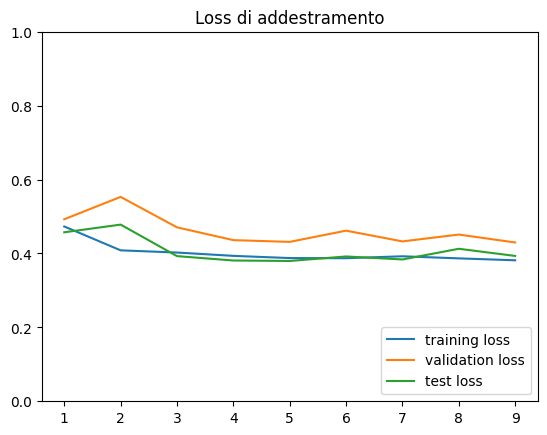

Train loss: [0.47290813407780213, 0.4083803325523565, 0.40242300688484567, 0.3934521205999233, 0.38747049279418994, 0.38710599383454264, 0.3922992319236567, 0.38664299507199984, 0.38144961220246776] - Test loss: [0.457212233543396, 0.4780095756053925, 0.3927484810352325, 0.38087109923362733, 0.37962756752967836, 0.39183810353279114, 0.38368443250656126, 0.4126082181930542, 0.39324105381965635] - Validation loss: [0.49248970879448783, 0.5529866019884745, 0.47058577669991386, 0.436025685734219, 0.43124045928319293, 0.46167182591226363, 0.43257970611254376, 0.45109352138307357, 0.4296570056014591]


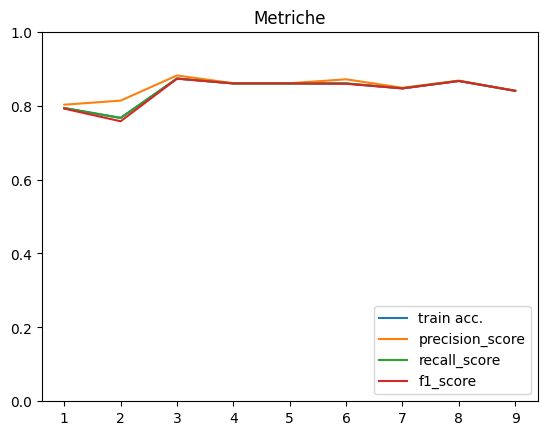

In [ ]:
import torch
import torch.nn as nn
from torchnn import *
from torch.utils.data import TensorDataset, random_split
import torch.optim as optim

#creo i miei tensori
X_tr_tensor = torch.tensor(X_tr_selected, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_selected, dtype=torch.float32)
y_tr_tensor = torch.tensor(y_tr.values, dtype=torch.long)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.long)
#da qui creo i dataset
train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

#effettuo lo split per generare il validation set
tr_dataset, val_dataset = random_split(train_dataset, lengths=[0.9, 0.1])
print(train_dataset)
print(tr_dataset)

#e costruisco i dataloader che userò per l'addestramento della rete
tr_dataloader, val_dataloader, test_dataloader = make_dataloaders(
    train_data=tr_dataset,
    val_data=val_dataset,
    test_data=test_dataset,
    batch=32
)


#Definizione Rete Neurale
class NeuralNetwork(nn.Module):
    def __init__(self, input_features):
        super().__init__()

        #parte densa (fully connected)
        self.network = nn.Sequential(
            #costruzione di due layer lineari che seguono una classificazione binaria
            #primo layer, senza dropout per consegna
            nn.Linear(input_features, 64),
            nn.ReLU(),
            #secondo layer
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            #layer di output
            nn.Linear(32, 2)  #2 per via della clseeificazione binaria
        )

    def forward(self, x):
        return self.network(x)
    

#dichiarazione Rete
model = NeuralNetwork(X_tr_selected.shape[1])
#ottimizzatore
opt = optim.RMSprop(model.parameters(), weight_decay=0.1, momentum=0.1, centered=True)

#logica di early stopping
class ModelCheckpoint(EarlyStopping):
    def __init__(self, patience, min_delta, path, val_loader):
        super().__init__(patience, min_delta)
        self.path = path
        self.val_loader = val_loader

        self.model = None
        self.optimizer = None
        self.current_epoch = 0
        self.max_validation_accuracy = 0.0

    def __call__(self, validation_loss):
        #incremento il contatore delle epoche che aumenta ogni volta che si entra in chiamata
        self.current_epoch += 1

        super().__call__(validation_loss)
        #spengo il dropout
        if self.model is not None:
            self.model.eval()
            correct = 0
            total = 0

        with torch.no_grad():
            for X, y in self.val_loader: 
                X, y = X.to('cpu'), y.to('cpu')
                logits = self.model(X)  #output
                predictions = logits.argmax(dim=1)

                correct += (predictions == y).sum().item()
                total += len(y)
        
        validation_accuracy = correct / total


        if validation_accuracy > self.max_validation_accuracy:
            self.max_validation_accuracy = validation_accuracy
            save_model(self.model, self.optimizer, self.current_epoch, [], [], [], [], {}, self.path)

early_stopping_checkpoint = ModelCheckpoint(patience=5, min_delta=0.01, path="save-path.pth", val_loader=val_dataloader)

#iniezione modello e ottimizzatore
early_stopping_checkpoint.model = model
early_stopping_checkpoint.optimizer = opt

print("Inizio addestramento Rete Neurale...")
tr_loss, val_loss, test_loss, accuracy, metrics = train_test(
    model=model,
    optimizer=opt,
    device = 'cpu',
    train_dataloader=tr_dataloader,
    val_dataloader=val_dataloader, 
    test_dataloader=test_dataloader,
    epochs=30,
    train_loss_fn=nn.CrossEntropyLoss(),
    test_loss_fn=nn.CrossEntropyLoss(),
    early_stopping=early_stopping_checkpoint
)

displayLosses(tr_loss, test_loss, val_loss)
print(f"Train loss: {tr_loss} - Test loss: {test_loss} - Validation loss: {val_loss}")
displayMetrics(accuracy, metrics)

4. Confrontare i risultati dei due classificatori calcolando e stampando, per ciascuno, la matrice di confusione, il valore di accuracy, la ROC e il valore di AUC calcolati sul test set. 

--- Modello SVM ---
Accuracy: 0.9600 | AUC: 0.9630
Matrice di Confusione:
[[73  2]
 [ 4 71]]

--- Rete Neurale ---
Accuracy: 0.8400 | AUC: 0.9204
Matrice di Confusione:
[[63 12]
 [12 63]]


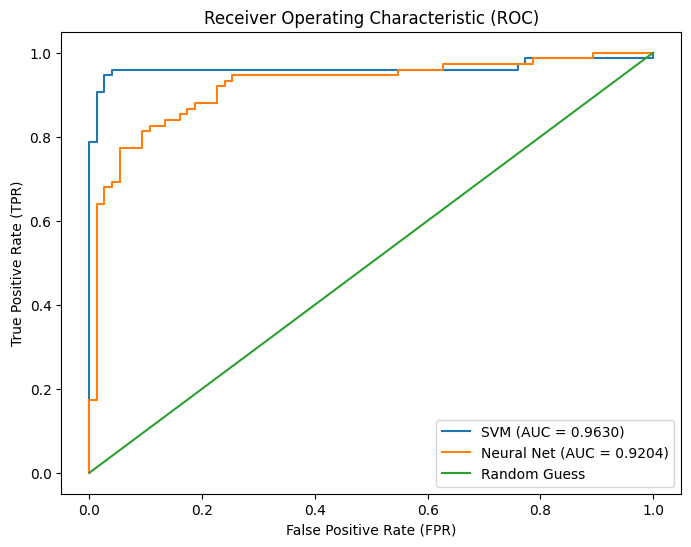

In [21]:
import matplotlib.pyplot as plot
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
import torch

# --- Valutazione Classificatore SVM ---
#per la predizione del modello e l'accuratezza del test set li abbiamo già calcolati nel punto 2:
#svm_predictions = clf_best_model.predict(X_test_selected) # Ottiene le predizioni discrete (0 o 1) del modello SVM sul test set
svm_predictions = model_prediction
#svm_acc = accuracy_score(y_test, svm_predictions) # Calcola l'accuratezza totale del modello SVM
svm_acc = test_accuracy

#adesso calcoliamo matrice di confusione, curva ROC e AUC sul test
svm_cm = confusion_matrix(y_test, svm_predictions) # Calcola la matrice di confusione confrontando le etichette reali con le predizioni SVM
svm_scores = clf_best_model.decision_function(X_test_selected) # Ottiene i punteggi di confidenza (necessari per calcolare la curva ROC, dato che non era attivo probability=True)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_scores) # Calcola il tasso di falsi positivi (FPR) e veri positivi (TPR) per la ROC della SVM
svm_auc = auc(svm_fpr, svm_tpr) # Calcola l'Area Sotto la Curva (AUC) basandosi su FPR e TPR della SVM

# --- Valutazione Rete Neurale (NN) ---
# model.eval() # Imposta la rete in modalità valutazione (disabilita eventuali strati come il Dropout)
with torch.no_grad(): # Disabilita il calcolo del gradiente (non serve in inferenza e fa risparmiare memoria)
    nn_logits = model(X_test_tensor) # Passa il test set alla rete per ottenere i logit grezzi
nn_prediction = nn_logits.argmax(dim=1).numpy() # Seleziona l'indice della probabilità maggiore come predizione (0 o 1)
nn_cm = confusion_matrix(y_test, nn_prediction) # Calcola la matrice di confusione per la Rete Neurale
nn_acc = accuracy_score(y_test, nn_prediction) # Calcola l'accuratezza totale per la Rete Neurale
nn_probs = torch.softmax(nn_logits, dim=1)[:, 1].numpy() # Applica softmax per ottenere la probabilità della classe positiva (1) e la converte in array NumPy
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_probs) # Calcola FPR e TPR per la curva ROC della Rete Neurale
nn_auc = auc(nn_fpr, nn_tpr) # Calcola il valore dell'Area Sotto la Curva (AUC) per la Rete Neurale

# --- Stampa delle Metriche ---
print(f"--- Modello SVM ---\nAccuracy: {svm_acc:.4f} | AUC: {svm_auc:.4f}\nMatrice di Confusione:\n{svm_cm}\n")
print(f"--- Rete Neurale ---\nAccuracy: {nn_acc:.4f} | AUC: {nn_auc:.4f}\nMatrice di Confusione:\n{nn_cm}")

# --- Plot Curve ROC ---
plt.figure(figsize=(8, 6)) # Crea la figura del grafico con dimensioni 8x6 pollici
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.4f})') # Traccia la curva ROC della SVM con la sua AUC in legenda
plt.plot(nn_fpr, nn_tpr, label=f'Neural Net (AUC = {nn_auc:.4f})') # Traccia la curva ROC della Rete Neurale con la sua AUC in legenda
plt.plot([0, 1], [0, 1], label='Random Guess') # Traccia la bisettrice tratteggiata nera che rappresenta un classificatore casuale
plt.title('Receiver Operating Characteristic (ROC)') # Assegna il titolo al grafico
plt.xlabel('False Positive Rate (FPR)') # Assegna l'etichetta all'asse delle ascisse (X)
plt.ylabel('True Positive Rate (TPR)') # Assegna l'etichetta all'asse delle ordinate (Y)
plt.legend(loc='lower right') # Posiziona la legenda in basso a destra per non coprire le curve
plt.show() # Mostra il grafico generato a schermo